In [1]:
import pandas as pd
import numpy as np


In [2]:
validation_config = {
    'strategy': 'stratified_k_fold',
    'n_folds': 5,
    'test_size': 0.2,
    'validation_size': 0.1,
    'random_state': 42,
    'metrics': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    'notes': 'Using weighted metrics for multiclass classification'
}

In [3]:
from sklearn.model_selection import train_test_split
def split_data_for_validation(X, y, test_size=0.2, random_state=42):
    """Splits data into train test and validation sets"""
    X_train, X_test, y_train, y_test = train_test_split(
        X,y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )


    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")

    return X_train, X_test, y_train, y_test


In [4]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def perform_cross_validation(models, X, y, n_folds=5, scoring_metrics=None):

    if scoring_metrics is None:
        scoring_metrics = {
            'accuracy': 'accuracy',
            'precision': make_scorer(precision_score, average='weighted'),
            'recall': make_scorer(recall_score, average='weighted'),
            'f1': make_scorer(f1_score, average='weighted'),
            'auc': make_scorer(roc_auc_score, average='weighted')
        }

    # Use stratified k-fold to maintain class distribution
    cv_strategy = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42
    )
    summary_list = []
    raw_results = {}
    for name, model in models.items():
        print(f"Training {name}...")
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifer', model)
        ])
        cv_results = cross_validate(
            pipeline, X, y,
            cv=cv_strategy,
            scoring=scoring_metrics,
            n_jobs=-1
        )
        #store raw results
        raw_results[name] = cv_results
    
        #calculate mean and std for each metric
        record = {'Model': name}
        for metric in scoring_metrics.keys():
            # cross_validate returns keys like 'test_accuracy', 'test_f1', etc.
            key_name = f"test_{metric}"
            mean_score = cv_results[key_name].mean()
            std_score = cv_results[key_name].std()
            record[metric] = f"{mean_score:.4f} +/- {std_score:.4f}"
            record[f"{metric}_mean"] = mean_score
    
        summary_list.append(record)

    df_summary = pd.DataFrame(summary_list)
    df_summary = df_summary.sort_values(by='f1_mean', ascending=False)
    
    #just to look clean
    display_cols = ['Model'] + list(scoring_metrics.keys())

    return df_summary[display_cols], raw_results

In [5]:
def plot_model_performance(raw_results, metric='test_f1'):
    """
    Creates a boxplot to visualize stability and performance spread.
    """
    plot_data = []
    for model_name, results in raw_results.items():
        scores = results[metric]
        for score in scores:
            plot_data.append({'Model': model_name, 'Score': score})
    
    df_plot = pd.DataFrame(plot_data)
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, x='Model', y='Score', hue='Model', palette='viridis', legend=False)
    plt.title(f'Model Comparison: {metric} Distribution ({len(df_plot)//len(raw_results)} folds)')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# SPLIT DATA AND TESTING
change models_to_test to models you want to get benchmarks for and change dataset to desired one.

In [13]:
dataset = pd.read_csv("processed_data.csv")
cols_train = [col for col in dataset.columns if "avg" in col]

X_train, X_test, y_train, y_test = split_data_for_validation(dataset[cols_train], dataset["result"])

Training set size: 1049
Test set size: 263


Training Logistic Regression...
Training Random Forest...
Training SVM...
Training KNN...
Training Decision Tree...

=== Model Leaderboard ===
              Model          accuracy         precision            recall                f1               auc
      Random Forest 0.6711 +/- 0.0226 0.6696 +/- 0.0249 0.6711 +/- 0.0226 0.6647 +/- 0.0213 0.6544 +/- 0.0204
      Decision Tree 0.6006 +/- 0.0263 0.6009 +/- 0.0261 0.6006 +/- 0.0263 0.6003 +/- 0.0264 0.5940 +/- 0.0263
                KNN 0.5462 +/- 0.0269 0.5410 +/- 0.0256 0.5462 +/- 0.0269 0.5416 +/- 0.0243 0.5318 +/- 0.0242
                SVM 0.5786 +/- 0.0237 0.5648 +/- 0.0389 0.5786 +/- 0.0237 0.5261 +/- 0.0316 0.5368 +/- 0.0258
Logistic Regression 0.5605 +/- 0.0145 0.5358 +/- 0.0251 0.5605 +/- 0.0145 0.5044 +/- 0.0236 0.5181 +/- 0.0163


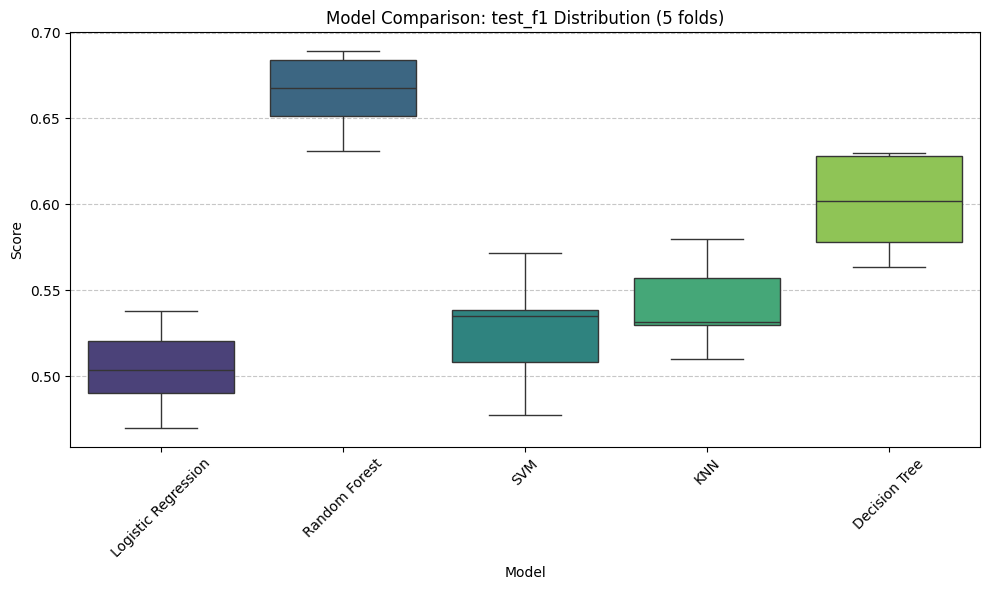

In [14]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
models_to_test = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# --- D. Run Comparison ---
df_results, raw_results = perform_cross_validation(models_to_test, X_train, y_train, n_folds=5)

# --- E. Display Results ---
print("\n=== Model Leaderboard ===")
print(df_results.to_string(index=False))

# --- F. Visualize ---
# Compare F1 scores visually
plot_model_performance(raw_results, metric='test_f1')